# 4 — Gradient Boosting

This chapter implements a **gradient boosting classifier** as a benchmark model for heart disease prediction. It complements the logistic regression (Chapter 3) by testing whether a more flexible, non-linear model achieves meaningfully better performance.

The model uses all 12 clinical features (without `source_code`). Hyperparameters are fixed — the dataset is too small (920 rows) for extensive tuning.

## Focus: Minimising False Negatives

As with logistic regression, the worst outcome is a **false negative**. We analyse multiple thresholds to minimise missed disease cases.

## Hyperparameters (fixed)

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 100 | Sufficient for a small dataset |
| `learning_rate` | 0.05 | Conservative, reduces overfitting |
| `max_depth` | 2 | Shallow trees prevent overfitting |
| `min_samples_leaf` | 5 | Prevents overly specific leaf nodes |
| `subsample` | 0.8 | Stochastic gradient boosting, adds regularisation |

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
    plot_roc_curve, classification_report_df,
)

FIGURES = "../results/figures"
TABLES  = "../results/tables"
MODELS  = "../results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue
CLR_RED   = "#CA6B6E"   # muted rose  (GBM primary)
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "pres_red", [CLR_GRAY, CLR_RED], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_RED,
    "axes.labelcolor": CLR_RED,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_RED,
    "xtick.color": CLR_RED,
    "ytick.color": CLR_RED,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 4.1 — Data Loading & Preparation

In [2]:
df = load_processed_data()
print(f"Shape: {df.shape}")
print(f"NaN values: {df.isna().sum().sum()}")

print(f"\nTarget distribution:")
print(df["num"].value_counts().sort_index())

Shape: (920, 14)
NaN values: 0

Target distribution:
num
0    411
1    509
Name: count, dtype: int64


In [3]:
# All clinical features, without source_code
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)
print(f"Features: {X.shape[1]}  "
      f"(cont={len(groups['continuous'])}, bin={len(groups['binary'])}, multi={len(groups['multiclass'])})")
print(f"Columns: {list(X.columns)}")

Features: 12  (cont=5, bin=3, multi=4)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']


In [4]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} samples  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})")
print(f"Test:  {len(X_test)} samples  (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")


Train: 736 samples  (pos=407, neg=329)
Test:  184 samples  (pos=102, neg=82)


## 4.2 — Model Training & Cross-Validation

We build a pipeline (ColumnTransformer → GradientBoostingClassifier) with fixed hyperparameters.

- `subsample = 0.8` works *inside* training: each boosting round uses a random 80% of training rows (stochastic gradient boosting, reduces overfitting).
- Cross-validation works *outside* the model: it estimates generalisation performance across 5 stratified folds.

In [5]:
# Fixed hyperparameters
GBC_PARAMS = dict(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

# Build pipeline
preprocessor = build_preprocessor(groups)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(**GBC_PARAMS)),
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold:   {np.round(cv_scores, 4)}")

# Fit on full training set
pipe.fit(X_train, y_train)

# Predict probabilities on test set
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC:  {test_auc:.4f}")
print(f"\nClassification report (default threshold = 0.5):")
print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))


CV ROC-AUC: 0.8742 ± 0.0253
Per fold:   [0.8519 0.8454 0.9042 0.8651 0.9042]

Test ROC-AUC:  0.9093

Classification report (default threshold = 0.5):
              precision    recall  f1-score   support

  No Disease       0.83      0.76      0.79        82
     Disease       0.82      0.87      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184



## 4.3 — Threshold Optimisation

The default threshold of 0.5 is not optimal for a medical screening tool. We examine the ROC curve to identify thresholds that maximise recall while keeping specificity reasonable.

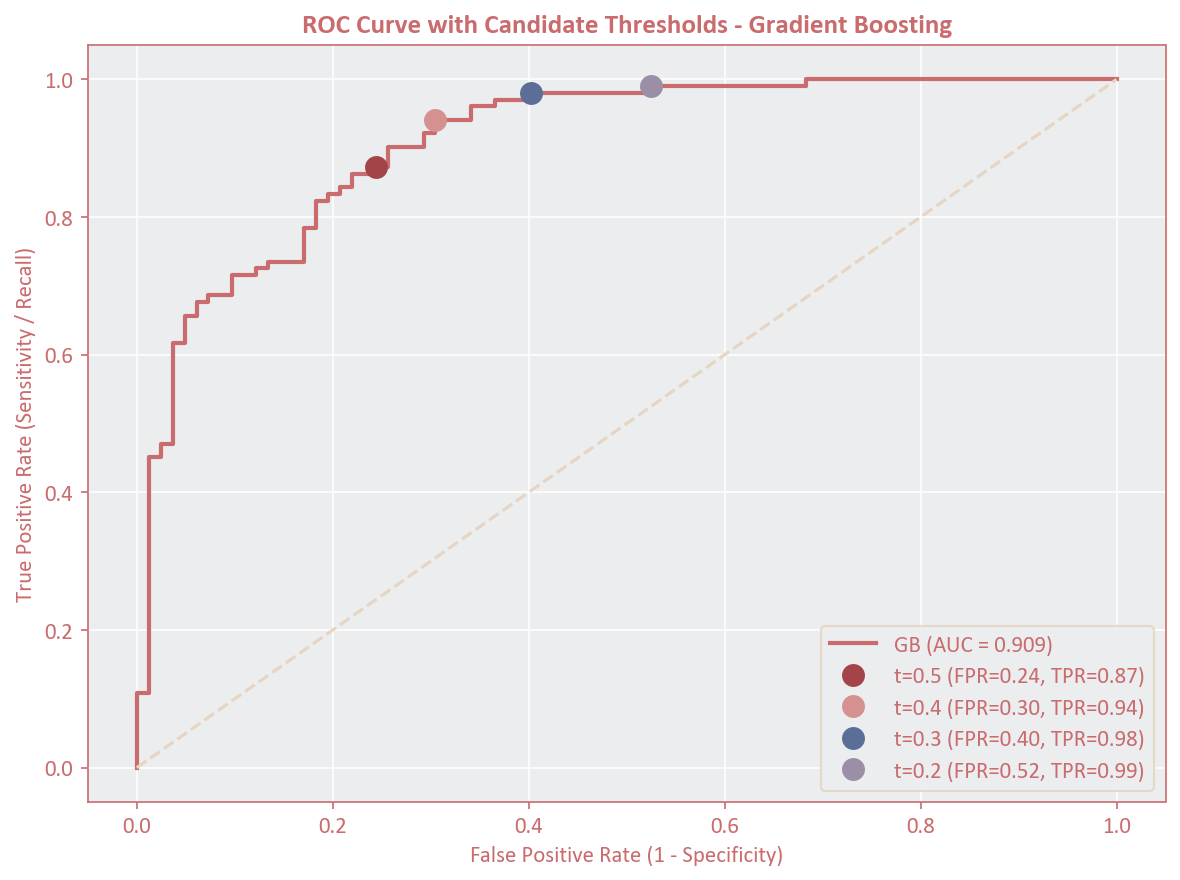

In [6]:
# ROC Curve with candidate thresholds marked
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Candidate thresholds to compare
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=CLR_RED, lw=2, label=f"GB (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark candidate thresholds on the ROC curve
marker_colors = ["#A34548", "#D4918F", "#5A6E97", "#9B8EA7"]
for thresh, color in zip(candidate_thresholds, marker_colors):
    # Find the closest threshold in the ROC curve
    idx = np.argmin(np.abs(thresholds - thresh))
    ax.plot(fpr[idx], tpr[idx], "o", color=color, markersize=10,
            label=f"t={thresh:.1f} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve with Candidate Thresholds - Gradient Boosting")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/gb_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 4.4 — Confusion Matrices at Different Thresholds

For each threshold, we show the confusion matrix. The critical cell is the **false negative (FN)** — actual disease predicted as no disease.

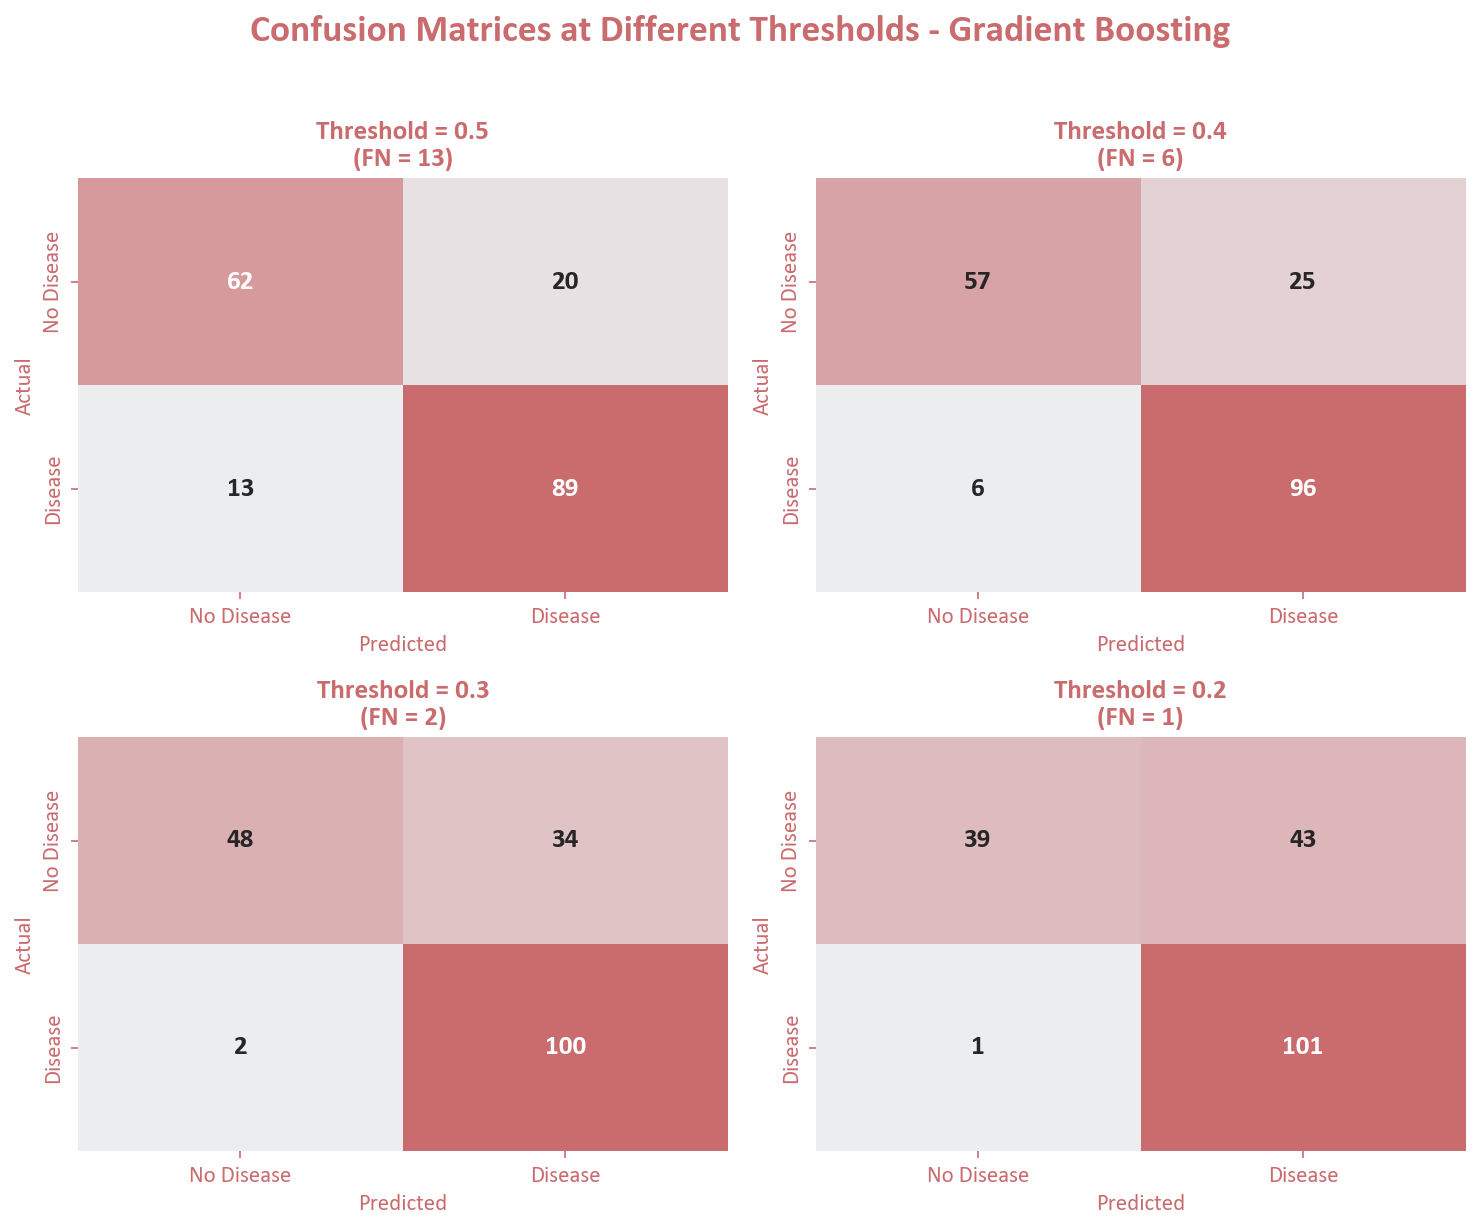

In [7]:
# Confusion matrices in 2x2 grid for all candidate thresholds
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, thresh in enumerate(candidate_thresholds):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap=CMAP_RED,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                ax=axes[i], cbar=False,
                annot_kws={"fontsize": 13, "fontweight": "bold"})
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].grid(False)
    
    fn = cm[1, 0]  # actual=Disease, predicted=No Disease
    axes[i].set_title(f"Threshold = {thresh}\n(FN = {fn})")

fig.suptitle("Confusion Matrices at Different Thresholds - Gradient Boosting", fontsize=18, y=1.02, fontweight="bold")
fig.savefig(f"{FIGURES}/gb_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [8]:
# Detailed metrics comparison across thresholds
rows = []
for thresh in candidate_thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    rows.append({
        "Threshold": thresh,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred_t),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_test, y_pred_t),
        "FN Rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(f"{TABLES}/gb_threshold_comparison.csv", index=False)

print("Threshold comparison (FN = missed disease cases):\n")
threshold_df.round(4)


Threshold comparison (FN = missed disease cases):



,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall (Sensitivity),Specificity,F1,FN Rate
0,0.5,89,20,13,62,0.8207,0.8165,0.8725,0.7561,0.8436,0.1275
1,0.4,96,25,6,57,0.8315,0.7934,0.9412,0.6951,0.8610,0.0588
2,0.3,100,34,2,48,0.8043,0.7463,0.9804,0.5854,0.8475,0.0196
3,0.2,101,43,1,39,0.7609,0.7014,0.9902,0.4756,0.8211,0.0098


### Threshold Selection Rationale

As with logistic regression, we select **t = 0.3** — it achieves high recall while keeping specificity above ~59%. The trade-off is clear: the cost of a missed disease (FN) far exceeds the cost of an unnecessary referral (FP).

## 4.5 — SHAP Analysis (Top 5 Variables)

SHAP (SHapley Additive exPlanations) computes exact feature contributions for tree-based models. We use SHAP to determine the **5 most influential variables** for the gradient boosting model. One-hot encoded features are aggregated back to their original variable names.

In [9]:
# Extract preprocessor and classifier from pipeline
preprocessor_fitted = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Transform data through preprocessor only
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get clean feature names
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

print(f"Transformed features ({len(feature_names)}):")
print(feature_names)

# Compute SHAP values
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)
shap_df = pd.DataFrame(shap_values, columns=feature_names)
print(f"\nSHAP values shape: {shap_df.shape}")

Transformed features (17):
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'thal_6.0', 'thal_7.0', 'slope_2.0', 'slope_3.0']

SHAP values shape: (184, 17)


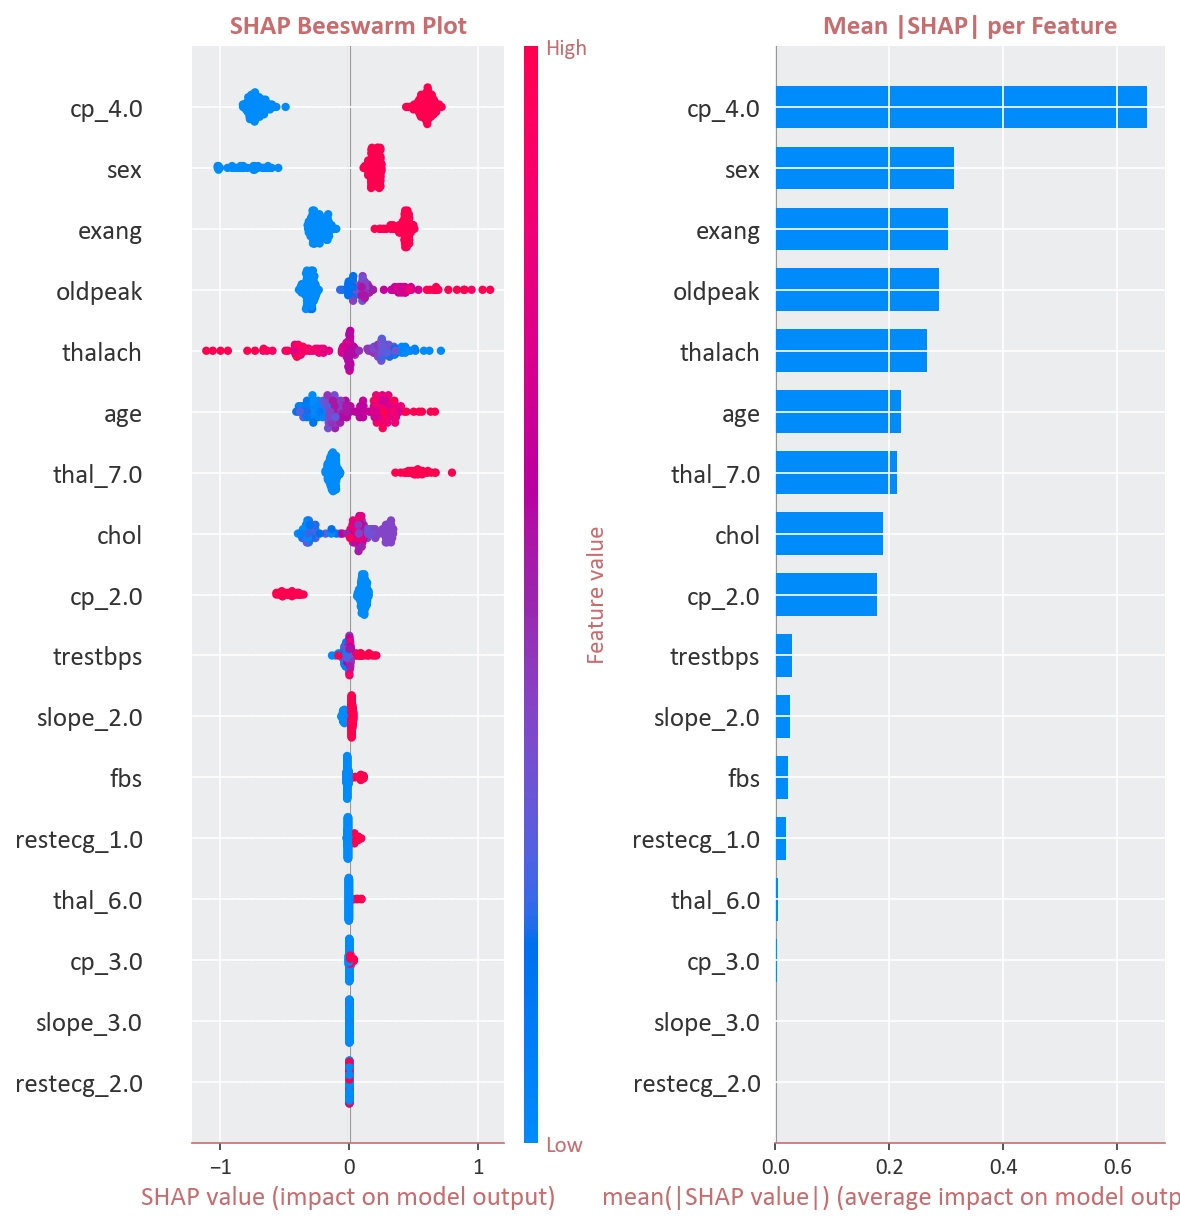

In [10]:
# SHAP Summary plot (beeswarm) and Bar plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
axes[0].set_title("SHAP Beeswarm Plot")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names,
                  plot_type="bar", show=False)
axes[1].set_title("Mean |SHAP| per Feature")

plt.tight_layout()
fig.savefig(f"{FIGURES}/gb_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# Aggregate one-hot SHAP values back to original feature names
_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

original_importance = {}
for col in feature_names:
    original = col
    for name in _MULTICLASS_ORIGINALS:
        if col.startswith(name + "_"):
            original = name
            break
    if original not in original_importance:
        original_importance[original] = 0.0
    original_importance[original] += np.abs(shap_df[col]).mean()

importance_df = (
    pd.DataFrame(list(original_importance.items()), columns=["feature", "mean_abs_shap"])
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance_df["rank"] = range(1, len(importance_df) + 1)
importance_df.to_csv(f"{TABLES}/gb_shap_importance.csv", index=False)

print("Feature importance (aggregated to original variables):\n")
print(importance_df.to_string(index=False))

print("\n" + "=" * 50)
print("TOP 5 MOST INFLUENTIAL VARIABLES (Gradient Boosting / SHAP)")
print("=" * 50)
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']:15s}  (mean |SHAP| = {row['mean_abs_shap']:.4f})")

Feature importance (aggregated to original variables):

 feature  mean_abs_shap  rank
      cp       0.833293     1
     sex       0.312978     2
   exang       0.303770     3
 oldpeak       0.287833     4
 thalach       0.266071     5
     age       0.220155     6
    thal       0.218889     7
    chol       0.188320     8
trestbps       0.028825     9
   slope       0.025624    10
     fbs       0.022317    11
 restecg       0.019763    12

TOP 5 MOST INFLUENTIAL VARIABLES (Gradient Boosting / SHAP)
  1. cp               (mean |SHAP| = 0.8333)
  2. sex              (mean |SHAP| = 0.3130)
  3. exang            (mean |SHAP| = 0.3038)
  4. oldpeak          (mean |SHAP| = 0.2878)
  5. thalach          (mean |SHAP| = 0.2661)


## 4.6 — Model Persistence & Summary

In [12]:
# Save model for reuse in Chapter 5
model_path = f"{MODELS}/gb_best_model.joblib"
joblib.dump(pipe, model_path)

# Summary at selected threshold (t=0.3)
t = 0.3
y_pred_t = (y_prob >= t).astype(int)
cm = confusion_matrix(y_test, y_pred_t)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("GRADIENT BOOSTING — FINAL RESULTS (all clinical features)")
print("=" * 60)
print(f"\nFeatures:         {X.shape[1]} (without source_code)")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Test ROC-AUC:     {test_auc:.4f}")
print(f"\nAt threshold t = {t}:")
print(f"  Sensitivity:    {recall_score(y_test, y_pred_t):.4f}")
print(f"  Precision:      {precision_score(y_test, y_pred_t):.4f}")
print(f"  Accuracy:       {accuracy_score(y_test, y_pred_t):.4f}")
print(f"  Specificity:    {tn / (tn + fp):.4f}")
print(f"  FN:             {fn}")
print(f"  FP:             {fp}")
print(f"\nTop 5 variables (SHAP):")
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']}")
print(f"\nModel saved to: {model_path}")

GRADIENT BOOSTING — FINAL RESULTS (all clinical features)

Features:         12 (without source_code)
CV ROC-AUC:       0.8742 +/- 0.0253
Test ROC-AUC:     0.9093

At threshold t = 0.3:
  Sensitivity:    0.9804
  Precision:      0.7463
  Accuracy:       0.8043
  Specificity:    0.5854
  FN:             2
  FP:             34

Top 5 variables (SHAP):
  1. cp
  2. sex
  3. exang
  4. oldpeak
  5. thalach

Model saved to: ../results/models/gb_best_model.joblib
